# HIỂN THỊ DANH SÁCH CÁC ẢNH CỦA TẬP DỮ LIỆU

1. Yêu cầu chung: Hiển thị một số ảnh trong bộ dữ liệu theo từng phân loại
  + Ví dụ minh họa:
  <IMG SRC = 'https://editor.analyticsvidhya.com/uploads/762161_OSvbuPLy0PSM2nZ62SbtlQ.png'>
2. Yêu cầu cụ thể:
  - Input: tập tin .csv, trong đó mỗi dòng tương ứng với (đường dẫn) một ảnh và categoryID. Ví dụ tập tin CarDataset-Splits-1-Train.csv
  - Output: như hình minh họa ở trên, mỗi dòng tương ứng với một CategoryID, số lượng ảnh, kích thước ảnh là các tham số với giá trị mặc định như sau
    + NumImgsPerRow = 10
    + ImgHeight = ImgWidth = 150
  - Các ảnh mỗi dòng được chọn ngẫu nhiên ở mỗi lần chạy

3. Nộp bài: SV share notebook. Các bài nộp sớm sẽ được full điểm. Deadline:

4. Bài làm đạt yêu cầu sẽ được paste vào notebook với ghi nhận đóng góp từ tác giả.

## Thông tin của tác giả, ngày cập nhật

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
!pip install ace_tools

In [3]:
import os
import pandas as pd

In [4]:
# Define the dataset path
dataset_path = "/content/drive/MyDrive/Public"  # Replace with the correct folder path

# Walk through the dataset directory to collect image paths and category labels
data = []
for root, dirs, files in os.walk(dataset_path):
    for file in files:
        if file.endswith(('.png', '.jpg', '.jpeg')):  # Acceptable image formats
            category = os.path.basename(root)  # Use folder name as CategoryID
            file_path = os.path.join(root, file)
            data.append([file_path, category])

# Create a DataFrame
df = pd.DataFrame(data, columns=['ImagePath', 'CategoryID'])

# Save the DataFrame as a CSV file
csv_file_path = '/content/CarDataset-Splits-1-Train.csv'
df.to_csv(csv_file_path, index=False)

# Instead of using ace_tools, display the DataFrame using pandas' head() method
# This will show the first 5 rows of the DataFrame
print("Image Category Dataset:")  # Print a descriptive title
df.head() #Display the first 5 rows

csv_file_path

Image Category Dataset:


'/content/CarDataset-Splits-1-Train.csv'

<ipython-input-5-74f01b573ceb>:55: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


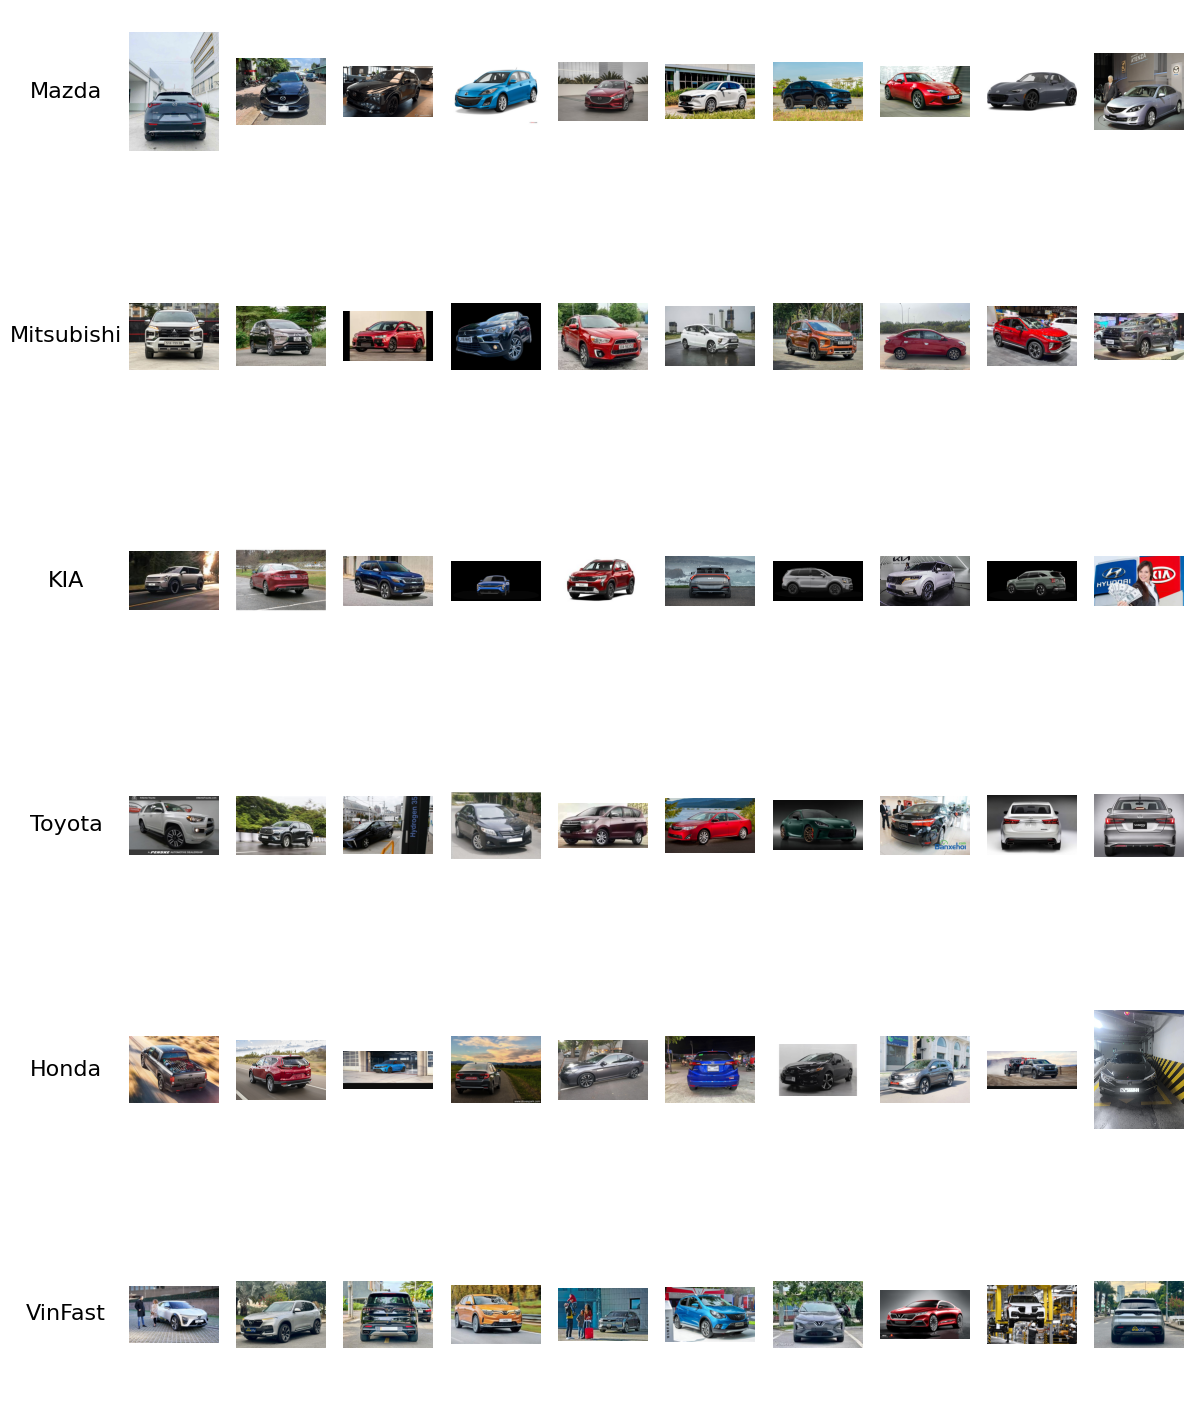

In [5]:
import os
import random
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from matplotlib.gridspec import GridSpec
from PIL import Image
# Constants
NumImgsPerRow = 10
ImgHeight = ImgWidth = 150

def read_image(img_path):
    try:
        img = Image.open(img_path)  # Open with PIL for format detection
        img = img.convert('RGB')  # Ensure compatibility for matplotlib
        img = mpimg.pil_to_array(img)  # Convert to NumPy array
        return img
    except (FileNotFoundError, IOError, SyntaxError):  # Catch errors
        return None  # Return None for missing or invalid images

categories = df['CategoryID'].unique()

# Select 6 random categories if there are more than 6
num_categories_to_display = min(len(categories), 6)
selected_categories = random.sample(list(categories), num_categories_to_display)

# Create the layout
fig = plt.figure(figsize=(15, num_categories_to_display * 3))  # Adjust figure height
gs = GridSpec(num_categories_to_display, NumImgsPerRow + 1,
              width_ratios=[1] + [1] * NumImgsPerRow,
              hspace=0.5)  # Add vertical spacing between rows


# Iterate through selected categories and display images
for row_index, category in enumerate(selected_categories):
    # Sample images for the current category
    category_images = df[df['CategoryID'] == category]['ImagePath'].tolist()
    sampled_images = random.sample(category_images, min(len(category_images), NumImgsPerRow))

    # Add the category title on the left
    ax_title = fig.add_subplot(gs[row_index, 0])  # Use row_index for subplot positioning
    ax_title.text(0.5, 0.5, category, fontsize=16, ha='center', va='center')
    ax_title.axis('off')

    # Add the images to the right
    for img_index, img_path in enumerate(sampled_images):
      ax = fig.add_subplot(gs[row_index, img_index + 1])  # Use row_index and img_index
      img = read_image(img_path)  # Use the read_image function
      if img is not None:  # Check if image loaded successfully
         ax.imshow(img)
         ax.axis('off')
      else:
        ax.axis('off')   # Skip missing images

plt.tight_layout()
plt.show()

In [6]:
# Đếm số lượng ảnh cho mỗi hãng xe
category_counts = df['CategoryID'].value_counts()

print("Số lượng ảnh cho mỗi hãng xe trong tập dataset:")

for category, count in category_counts.items():
    print(f"{category}: {count}")


Số lượng ảnh cho mỗi hãng xe trong tập dataset:
Suzuki: 6940
Toyota: 6192
Others: 4593
Hyundai: 3792
KIA: 3517
Mazda: 3433
Honda: 3280
Mitsubishi: 3178
VinFast: 3098
